# Sheet 03: Exploratory Data Analysis (EDA)

Explore distributions, relationships, and patterns in the cleaned dataset to
uncover insights about antimicrobial resistance across countries, bacteria,
antibiotics, and years. These findings inform both the model and the dashboard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# use the CLEANED data (with resistance_level), not the raw file
df = pd.read_csv("../data/processed/ears_net_clean.csv")

# make charts look nicer by default
sns.set_style("whitegrid")

print("Loaded:", df.shape)
df.head()

Loaded: (3422, 7)


,country,year,bacterium,antibiotic,n_isolates,pct_resistant,resistance_level
0,Austria,2013,Acinetobacter spp.,Aminoglycosides,51.0,9.80000,Low
1,Austria,2014,Acinetobacter spp.,Aminoglycosides,79.0,8.86076,Low
2,Bulgaria,2012,Acinetobacter spp.,Aminoglycosides,65.0,58.50000,High
3,Bulgaria,2013,Acinetobacter spp.,Aminoglycosides,91.0,58.20000,High
4,Bulgaria,2014,Acinetobacter spp.,Aminoglycosides,99.0,63.63636,High


## 1. Distribution of Resistance Levels (the target)

How balanced are the Low / Medium / High classes?

C:\Users\META\AppData\Local\Temp\ipykernel_25016\1864177973.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='resistance_level', order=['Low', 'Medium', 'High'],


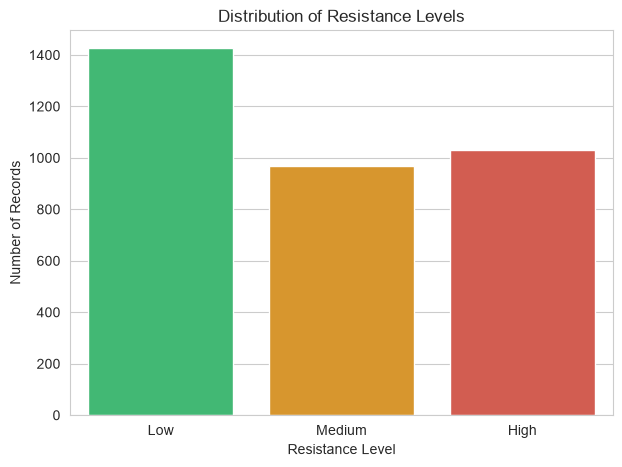

In [2]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='resistance_level', order=['Low', 'Medium', 'High'],
              palette=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Distribution of Resistance Levels')
plt.xlabel('Resistance Level')
plt.ylabel('Number of Records')
plt.show()

**Insight:** The three classes are reasonably balanced (Low ≈ 1425, High ≈ 1030,
Medium ≈ 967), so no class dominates. This makes accuracy a valid metric and
avoids the model being biased toward a majority class.

## 2. Average Resistance by Antibiotic

Which antibiotics show the highest resistance across all countries?

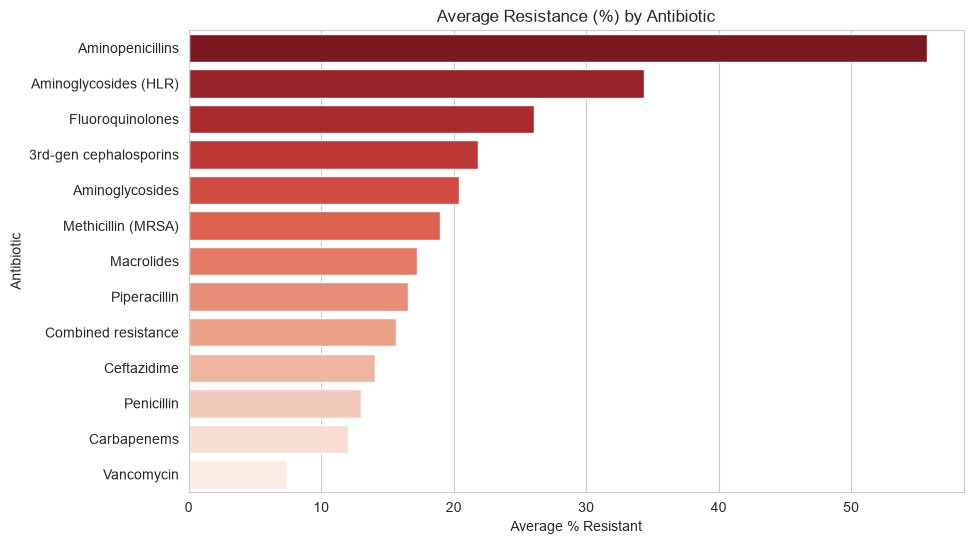

antibiotic
Aminopenicillins          55.7
Aminoglycosides (HLR)     34.4
Fluoroquinolones          26.1
3rd-gen cephalosporins    21.8
Aminoglycosides           20.4
Methicillin (MRSA)        18.9
Macrolides                17.2
Piperacillin              16.6
Combined resistance       15.7
Ceftazidime               14.0
Penicillin                13.0
Carbapenems               12.1
Vancomycin                 7.4
Name: pct_resistant, dtype: float64


In [3]:
plt.figure(figsize=(10, 6))
avg_by_antibiotic = df.groupby('antibiotic')['pct_resistant'].mean().sort_values(ascending=False)
sns.barplot(x=avg_by_antibiotic.values, y=avg_by_antibiotic.index, palette='Reds_r', hue=avg_by_antibiotic.index, legend=False)
plt.title('Average Resistance (%) by Antibiotic')
plt.xlabel('Average % Resistant')
plt.ylabel('Antibiotic')
plt.show()

print(avg_by_antibiotic.round(1))

## 3. Average Resistance by Country

Which countries show the highest overall resistance?

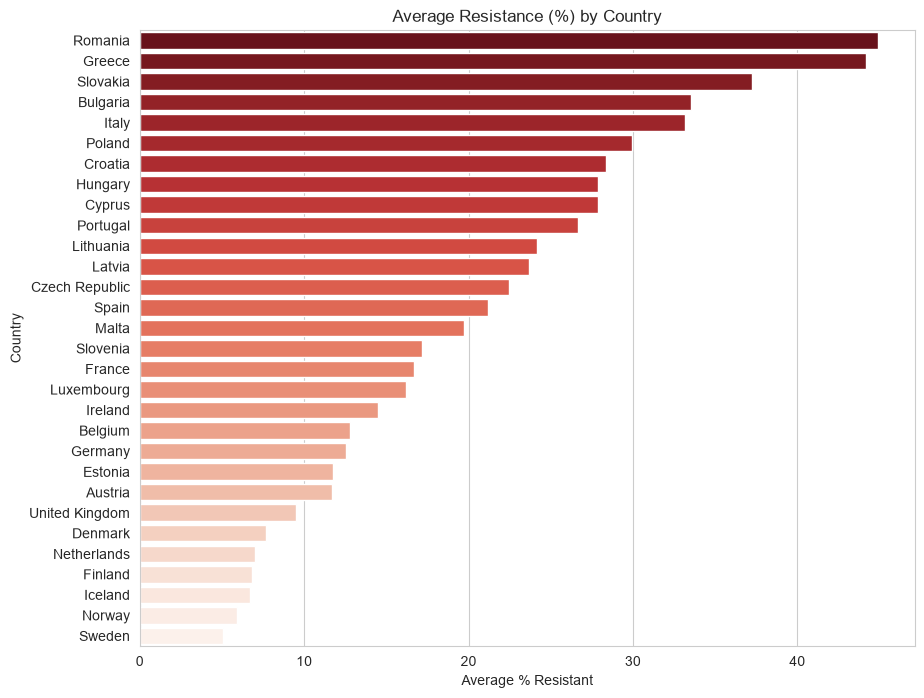

Top 5 highest resistance countries:
country
Romania     44.9
Greece      44.2
Slovakia    37.3
Bulgaria    33.5
Italy       33.2
Name: pct_resistant, dtype: float64

Top 5 lowest resistance countries:
country
Netherlands    7.0
Finland        6.8
Iceland        6.7
Norway         5.9
Sweden         5.1
Name: pct_resistant, dtype: float64


In [4]:
plt.figure(figsize=(10, 8))
avg_by_country = df.groupby('country')['pct_resistant'].mean().sort_values(ascending=False)
sns.barplot(x=avg_by_country.values, y=avg_by_country.index, palette='Reds_r', hue=avg_by_country.index, legend=False)
plt.title('Average Resistance (%) by Country')
plt.xlabel('Average % Resistant')
plt.ylabel('Country')
plt.show()

print("Top 5 highest resistance countries:")
print(avg_by_country.head().round(1))
print("\nTop 5 lowest resistance countries:")
print(avg_by_country.tail().round(1))

## 4. Resistance Trend Over Time (2010–2014)

Is antimicrobial resistance increasing, decreasing, or stable over the years?

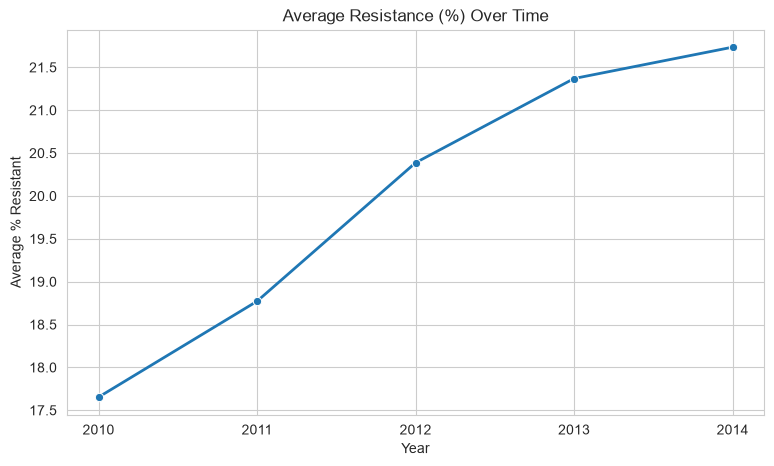

year
2010    17.65
2011    18.77
2012    20.39
2013    21.37
2014    21.74
Name: pct_resistant, dtype: float64


In [5]:
plt.figure(figsize=(9, 5))
avg_by_year = df.groupby('year')['pct_resistant'].mean()
sns.lineplot(x=avg_by_year.index, y=avg_by_year.values, marker='o', linewidth=2)
plt.title('Average Resistance (%) Over Time')
plt.xlabel('Year')
plt.ylabel('Average % Resistant')
plt.xticks(avg_by_year.index)
plt.show()

print(avg_by_year.round(2))

In [6]:
# Feature engineering: group countries into European regions
region_map = {
    # Northern / Nordic
    'Sweden': 'Northern', 'Norway': 'Northern', 'Iceland': 'Northern',
    'Finland': 'Northern', 'Denmark': 'Northern', 'Estonia': 'Northern',
    'Latvia': 'Northern', 'Lithuania': 'Northern',
    # Western
    'Netherlands': 'Western', 'Belgium': 'Western', 'Luxembourg': 'Western',
    'France': 'Western', 'Ireland': 'Western', 'United Kingdom': 'Western',
    'Germany': 'Western', 'Austria': 'Western',
    # Southern
    'Italy': 'Southern', 'Spain': 'Southern', 'Portugal': 'Southern',
    'Greece': 'Southern', 'Malta': 'Southern', 'Cyprus': 'Southern',
    'Croatia': 'Southern', 'Slovenia': 'Southern',
    # Eastern
    'Romania': 'Eastern', 'Bulgaria': 'Eastern', 'Slovakia': 'Eastern',
    'Poland': 'Eastern', 'Hungary': 'Eastern', 'Czech Republic': 'Eastern',
}
df['region'] = df['country'].map(region_map)

# verify the pattern
print(df.groupby('region')['pct_resistant'].mean().round(1).sort_values())

region
Northern    11.3
Western     12.6
Southern    27.3
Eastern     32.5
Name: pct_resistant, dtype: float64


## Key Insights from EDA

**1. A stark North–South divide.** The five highest-resistance countries are all in
Southern/Eastern Europe (Romania 44.9%, Greece 44.2%, Slovakia 37.3%, Bulgaria 33.5%,
Italy 33.2%), while the five lowest are all Nordic/Northern (Sweden 5.1%, Norway 5.9%,
Iceland 6.7%, Finland 6.8%, Netherlands 7.0%). Southern/Eastern resistance is roughly
**6–8× higher** than the Nordic countries.

**2. Some antibiotics are already failing.** Aminopenicillins average 55.7% resistance —
over half of infections no longer respond — followed by high-level-resistance
Aminoglycosides (34.4%) and Fluoroquinolones (26.1%). Last-resort drugs remain more
effective: Carbapenems (12.1%) and Vancomycin (7.4%).

**3. Resistance is rising over time.** Average resistance climbed steadily from 17.65%
(2010) to 21.74% (2014) — a ~4 percentage-point increase in five years, confirming AMR
is worsening, not stabilising.

## Data-Driven Recommendations

- **Target interventions geographically.** Antibiotic stewardship funding and infection-
  control programmes should prioritise the high-resistance cluster (Romania, Greece,
  Slovakia, Bulgaria, Italy) rather than spreading resources evenly across the EU.

- **Protect the last-resort drugs.** Carbapenems and Vancomycin still work; their use
  should be tightly controlled to prevent resistance developing, since alternatives like
  Aminopenicillins are already ineffective (>50% resistant).

- **Act on the upward trend.** The steady 2010–2014 rise means current policies are not
  containing resistance; escalated surveillance and prescribing controls are warranted.

- **Learn from the Nordic model.** The low-resistance countries (conservative prescribing,
  strong surveillance) offer a proven template that higher-resistance countries could adopt.

In [8]:
df.to_csv("../data/processed/ears_net_clean.csv", index=False)
print("Saved with region column. Columns:", list(df.columns))

Saved with region column. Columns: ['country', 'year', 'bacterium', 'antibiotic', 'n_isolates', 'pct_resistant', 'resistance_level', 'region']
